In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
print(" All libraries imported successfully!")

 All libraries imported successfully!


In [63]:
# Load the dataset
df = pd.read_csv('Housing.csv')

# First 10 rows
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,furnished


In [65]:
# Shape of the dataset
rows, cols = df.shape
print(f"Dataset contains {rows} rows and {cols} columns")
print(f"\nTarget column   : price")
print(f"Feature columns : {[c for c in df.columns if c != 'price']}")

Dataset contains 99 rows and 13 columns

Target column   : price
Feature columns : ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [66]:
# Data types
print("Data types of each column:")
print(df.dtypes)

Data types of each column:
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object


In [67]:
# Missing values check
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Total missing values: 0


In [68]:
# Step 1: Remove duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"Removed {before - after} duplicate row(s). Rows remaining: {after}")

Removed 0 duplicate row(s). Rows remaining: 99


In [69]:
# Step 2: Missing values — none found, but handle just in case
df.fillna(df.median(numeric_only=True), inplace=True)
print("Missing value handling complete.")

Missing value handling complete.


In [70]:
# Step 3: Encode binary yes/no columns → 0/1
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
               'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

print("Binary columns encoded:")
print(df[binary_cols].head())

Binary columns encoded:
   mainroad  guestroom  basement  hotwaterheating  airconditioning  prefarea
0         1          0         0                0                1         1
1         1          0         0                0                1         0
2         1          0         1                0                0         1
3         1          0         1                0                1         1
4         1          1         1                0                1         0


In [71]:
# Step 4: One-hot encode furnishingstatus
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=False)

# Convert boolean columns to int
bool_cols = [c for c in df.columns if df[c].dtype == bool]
df[bool_cols] = df[bool_cols].astype(int)

print("One-hot encoding done. Final columns:")
print(df.columns.tolist())
df.head()

One-hot encoding done. Final columns:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_furnished', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1,0,0


In [72]:
# Split features and target
X = df.drop('price', axis=1)
y = df['price']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Training samples : 79
Testing  samples : 20


In [73]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("📈 Linear Regression Results")
print(f"   MAE  : ₹{mae_lr:>12,.0f}")
print(f"   RMSE : ₹{rmse_lr:>12,.0f}")
print(f"   R²   : {r2_lr:.4f}")

📈 Linear Regression Results
   MAE  : ₹     894,817
   RMSE : ₹   1,287,718
   R²   : 0.7321


In [74]:
# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print(f"   MAE  : ₹{mae_rf:>12,.0f}")
print(f"   RMSE : ₹{rmse_rf:>12,.0f}")
print(f"   R²   : {r2_rf:.4f}")

Random Forest Results
   MAE  : ₹     628,624
   RMSE : ₹   1,203,545
   R²   : 0.7660


In [75]:
# Model Comparison Table
comparison = pd.DataFrame({
    'Model'   : ['Linear Regression', 'Random Forest'],
    'MAE (₹)' : [f'{mae_lr:,.0f}', f'{mae_rf:,.0f}'],
    'RMSE (₹)': [f'{rmse_lr:,.0f}', f'{rmse_rf:,.0f}'],
    'R² Score': [f'{r2_lr:.4f}', f'{r2_rf:.4f}'],
    'Winner'  : ['', 'Better']
})
print("\n Model Comparison:")
print(comparison.to_string(index=False))


 Model Comparison:
            Model MAE (₹)  RMSE (₹) R² Score Winner
Linear Regression 894,817 1,287,718   0.7321       
    Random Forest 628,624 1,203,545   0.7660 Better


In [76]:
import os
os.makedirs('charts', exist_ok=True)
print("charts folder is created")

charts folder is created


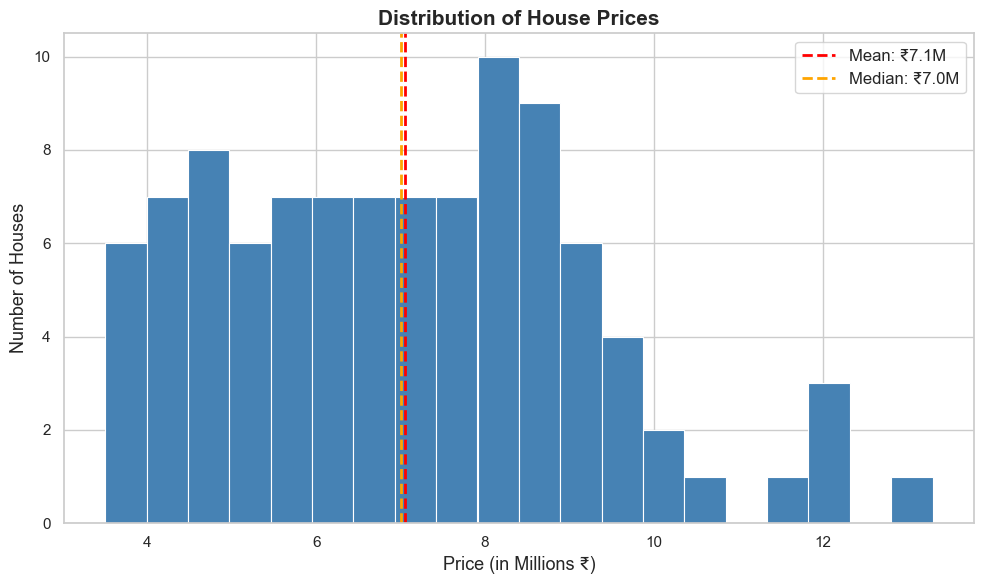

Chart 1 saved.


In [77]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df['price'] / 1e6, bins=20, color='steelblue', edgecolor='white', linewidth=0.8)
ax.axvline(df['price'].mean() / 1e6, color='red', linestyle='--', linewidth=2,
           label=f"Mean: ₹{df['price'].mean()/1e6:.1f}M")
ax.axvline(df['price'].median() / 1e6, color='orange', linestyle='--', linewidth=2,
           label=f"Median: ₹{df['price'].median()/1e6:.1f}M")
ax.set_xlabel('Price (in Millions ₹)', fontsize=13)
ax.set_ylabel('Number of Houses', fontsize=13)
ax.set_title('Distribution of House Prices', fontsize=15, fontweight='bold')
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=150)
plt.show()
print("Chart 1 saved.")

In [78]:
import os
os.makedirs('charts', exist_ok=True)
print("charts folder is created!")

charts folder is created!


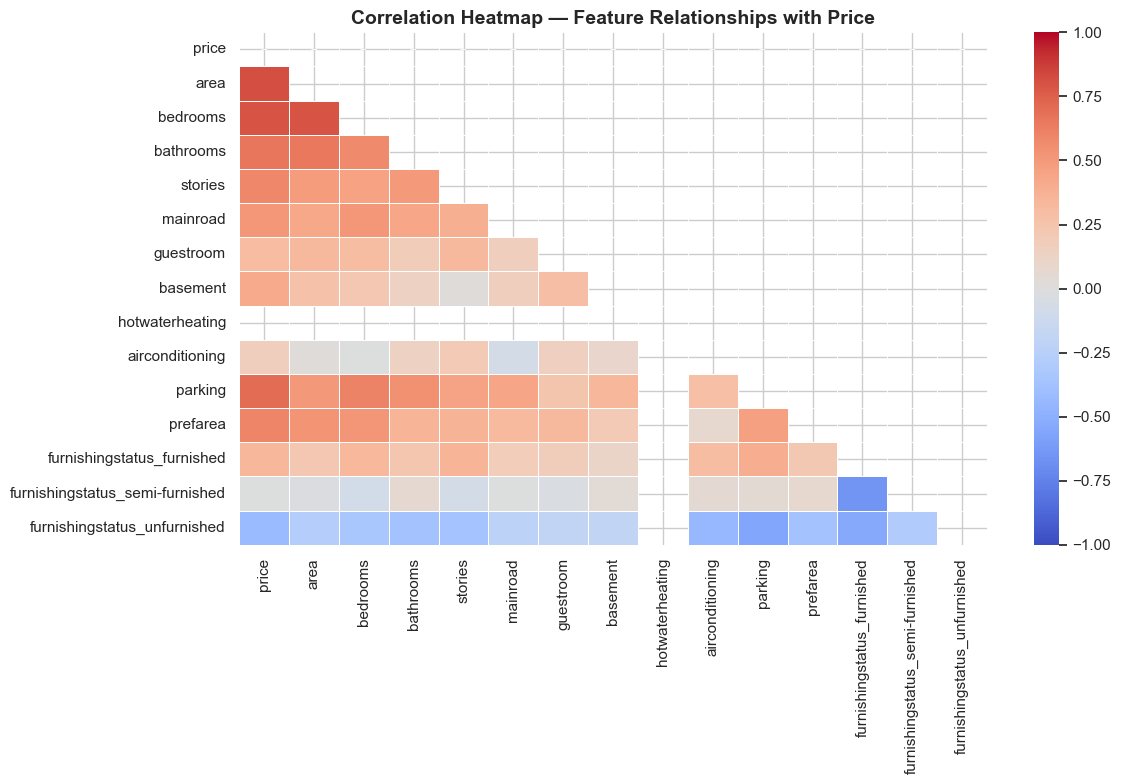

Chart 2 saved.


In [79]:
fig, ax = plt.subplots(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 8},
            vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap — Feature Relationships with Price',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', dpi=150)
plt.show()
print("Chart 2 saved.")

In [80]:
import os
os.makedirs('charts', exist_ok=True)
print("charts folder is created!")

charts folder is created!


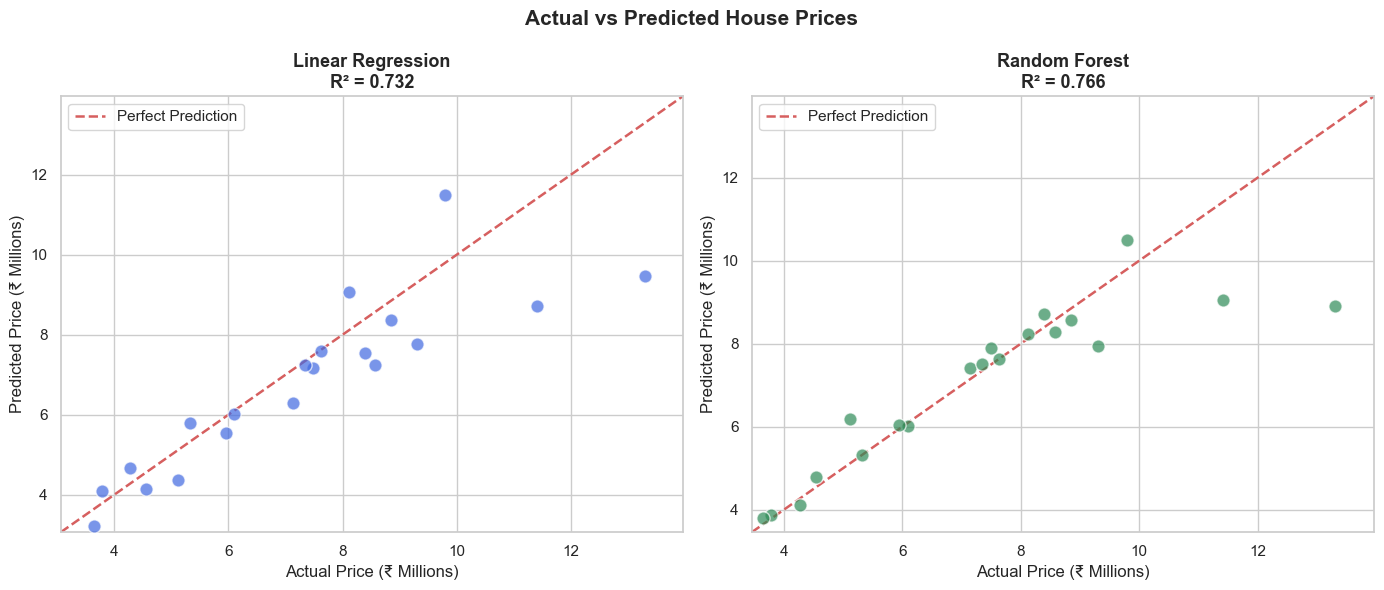

Chart 3 saved.


In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, title, color, r2 in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Linear Regression', 'Random Forest'],
    ['royalblue', 'seagreen'],
    [r2_lr, r2_rf]
):
    ax.scatter(y_test / 1e6, y_pred / 1e6, alpha=0.7, color=color,
               edgecolors='white', s=90, zorder=3)
    lims = [
        min(y_test.min(), min(y_pred)) / 1e6 * 0.95,
        max(y_test.max(), max(y_pred)) / 1e6 * 1.05
    ]
    ax.plot(lims, lims, 'r--', linewidth=1.8, label='Perfect Prediction', zorder=2)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual Price (₹ Millions)', fontsize=12)
    ax.set_ylabel('Predicted Price (₹ Millions)', fontsize=12)
    ax.set_title(f'{title}\nR² = {r2:.3f}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)

fig.suptitle('Actual vs Predicted House Prices', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png', dpi=150)
plt.show()
print("Chart 3 saved.")

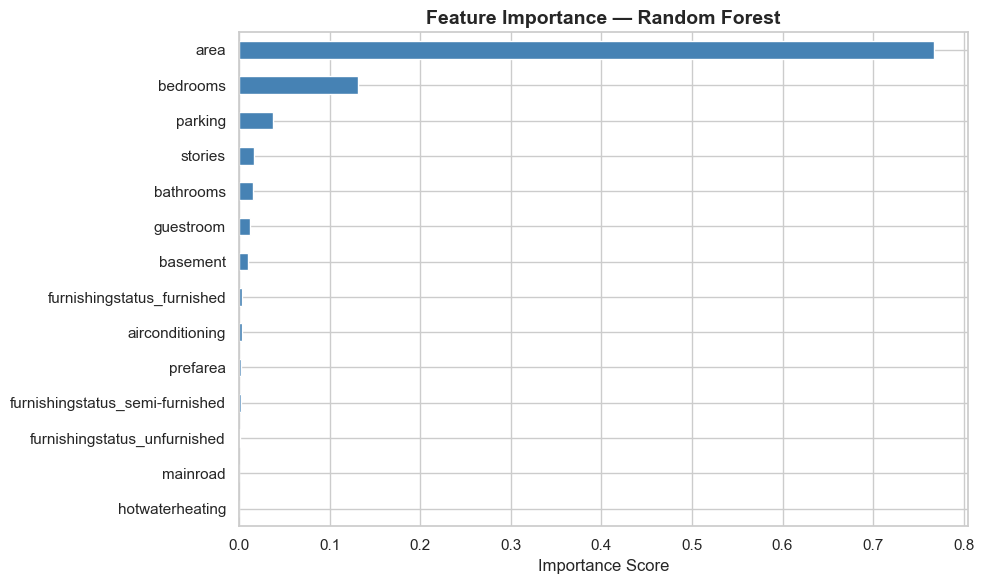


Top 5 Most Important Features:
area         0.766720
bedrooms     0.131299
parking      0.037542
stories      0.016013
bathrooms    0.015146


In [82]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.plot(kind='barh', color='steelblue', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(feat_imp.head(5).to_string())

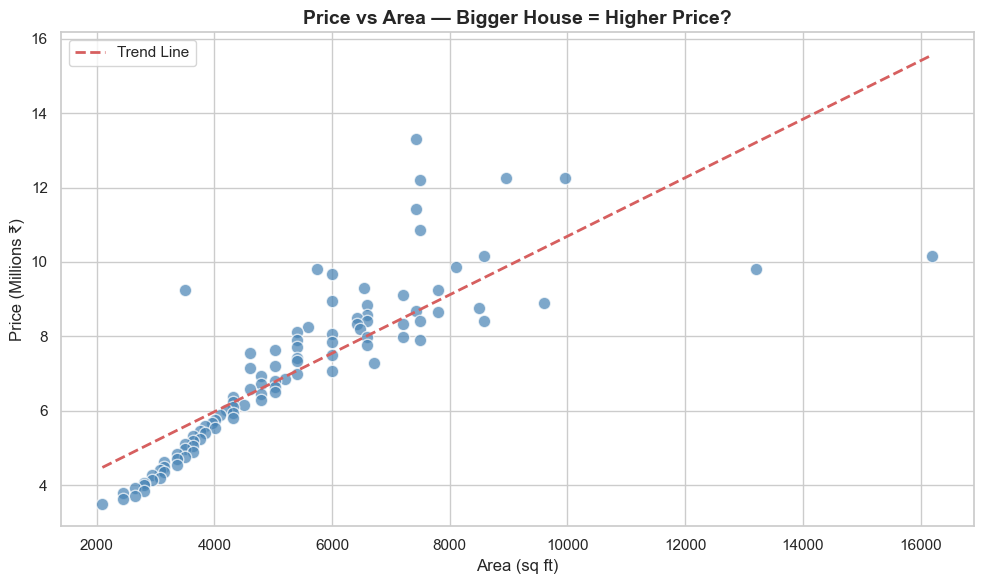

✅ Chart 5 saved!


In [83]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['area'], df['price'] / 1e6, 
           alpha=0.7, color='steelblue', 
           edgecolors='white', s=80)
ax.set_xlabel('Area (sq ft)', fontsize=12)
ax.set_ylabel('Price (Millions ₹)', fontsize=12)
ax.set_title('Price vs Area — Bigger House = Higher Price?', 
             fontsize=14, fontweight='bold')

# Trend line add karo
z = np.polyfit(df['area'], df['price'] / 1e6, 1)
p = np.poly1d(z)
ax.plot(sorted(df['area']), p(sorted(df['area'])), 
        'r--', linewidth=2, label='Trend Line')
ax.legend()
plt.tight_layout()
plt.savefig('charts/chart5_price_vs_area.png', dpi=150)
plt.show()
print("✅ Chart 5 saved!")

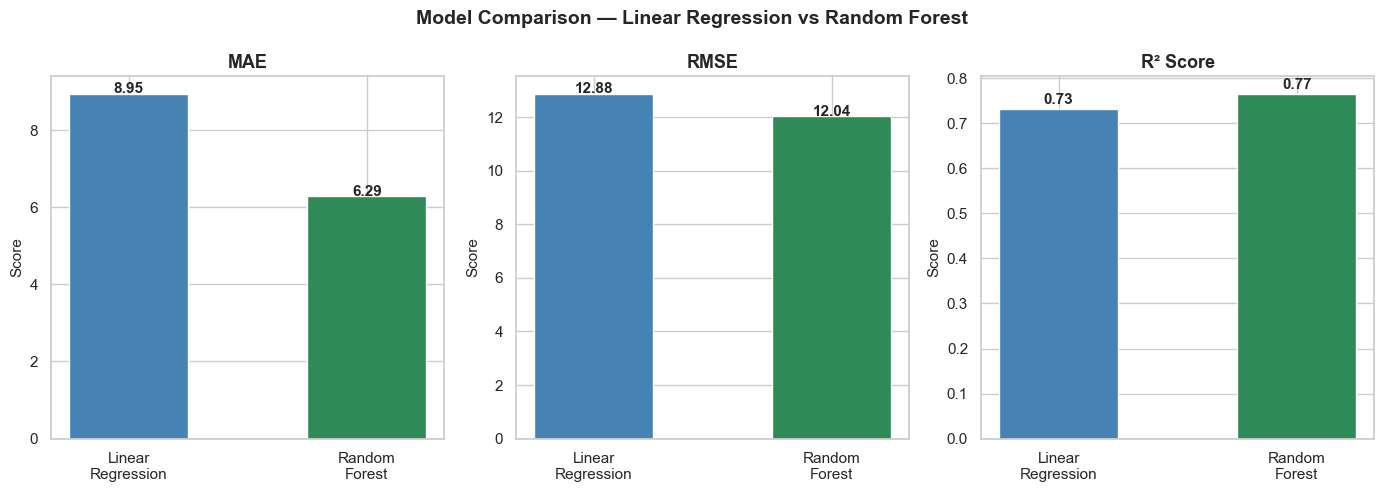

✅ Chart 6 saved!


In [84]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['MAE', 'RMSE', 'R² Score']
lr_vals  = [mae_lr/1e5, rmse_lr/1e5, r2_lr]
rf_vals  = [mae_rf/1e5, rmse_rf/1e5, r2_rf]

colors = ['steelblue', 'seagreen']

for i, (ax, metric) in enumerate(zip(axes, metrics)):
    bars = ax.bar(['Linear\nRegression', 'Random\nForest'], 
                  [lr_vals[i], rf_vals[i]], 
                  color=colors, edgecolor='white', width=0.5)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score', fontsize=11)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, 
                bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', 
                ha='center', fontsize=11, fontweight='bold')

fig.suptitle('Model Comparison — Linear Regression vs Random Forest', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart6_model_comparison.png', dpi=150)
plt.show()
print("✅ Chart 6 saved!")

In [85]:
import subprocess
subprocess.run(['pip', 'install', 'python-docx', '--user'], 
               capture_output=True)
print("Done!")

Done!


In [86]:
from docx import Document
from docx.shared import Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH

doc = Document()

# Title
title = doc.add_heading('House Price Prediction', 0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

sub = doc.add_paragraph('Internship Project — Week 1 Summary Report')
sub.alignment = WD_ALIGN_PARAGRAPH.CENTER

doc.add_paragraph('Dataset: Housing Prices Dataset  |  Date: 17 May 2026').alignment = WD_ALIGN_PARAGRAPH.CENTER

doc.add_paragraph('')

# Section 1
doc.add_heading('1. Project Overview', level=1)
doc.add_paragraph('The objective was to build a regression model to predict house prices based on features like area, bedrooms, bathrooms, and amenities using the Housing Prices Dataset (99 records, 13 features).')

# Section 2
doc.add_heading('2. Dataset Summary', level=1)
table = doc.add_table(rows=7, cols=2)
table.style = 'Table Grid'
headers = ['Attribute', 'Details']
data = [
    ['Total Records', '99 rows'],
    ['Total Features', '13 columns'],
    ['Target Variable', 'price'],
    ['Missing Values', 'None'],
    ['Duplicate Rows', '0 removed'],
    ['Encoding', 'yes/no → 0/1 | furnishingstatus → one-hot']
]
for i, (k, v) in enumerate(data):
    table.rows[i+1].cells[0].text = k
    table.rows[i+1].cells[1].text = v
table.rows[0].cells[0].text = headers[0]
table.rows[0].cells[1].text = headers[1]

doc.add_paragraph('')

# Section 3
doc.add_heading('3. Model Performance', level=1)
mtable = doc.add_table(rows=3, cols=4)
mtable.style = 'Table Grid'
mdata = [
    ['Model', 'MAE', 'RMSE', 'R²'],
    ['Linear Regression', '8,94,817', '12,87,718', '0.7321'],
    ['Random Forest ✅', '6,28,624', '12,03,545', '0.7660']
]
for i, row in enumerate(mdata):
    for j, val in enumerate(row):
        mtable.rows[i].cells[j].text = val

doc.add_paragraph('')

# Section 4
doc.add_heading('4. Key Findings', level=1)
doc.add_heading('Most Important Features:', level=2)
doc.add_paragraph('Area is the strongest predictor (76.7%), followed by bedrooms (13.1%) and parking (3.7%).')
doc.add_heading('Model Accuracy:', level=2)
doc.add_paragraph('Random Forest achieved R² = 0.766, meaning 76.6% accuracy. Average error was ₹6.3 lakh.')
doc.add_heading('Surprising Finding:', level=2)
doc.add_paragraph('Hot water heating showed almost no correlation with price despite being a premium feature.')
doc.add_heading('Business Recommendation:', level=2)
doc.add_paragraph('Real estate companies should highlight property area prominently — it is the single biggest driver of house price.')

# Section 5
doc.add_heading('5. Visualizations', level=1)
doc.add_paragraph('Chart 1: chart1_price_distribution.png — Price distribution histogram')
doc.add_paragraph('Chart 2: chart2_correlation_heatmap.png — Feature correlation heatmap')
doc.add_paragraph('Chart 3: chart3_actual_vs_predicted.png — Actual vs Predicted prices')

doc.save('summary.docx')
print("summary.docx is created!")

summary.docx is created!


In [87]:
# Final Status Table
doc.add_heading('6. Project Completion Status', level=1)
stable = doc.add_table(rows=6, cols=2)
stable.style = 'Table Grid'
status_data = [
    ['Task', 'Status'],
    ['Data Loading & Exploration', '✅ Done'],
    ['Data Cleaning', '✅ Done'],
    ['Model Building (LR + RF)', '✅ Done'],
    ['Visualizations (3 charts)', '✅ Done'],
    ['Insights & Summary', '✅ Done'],
]
for i, row in enumerate(status_data):
    stable.rows[i].cells[0].text = row[0]
    stable.rows[i].cells[1].text = row[1]

doc.add_paragraph('')
footer = doc.add_paragraph('Generated for Week 1 Internship Submission | May 2026')
footer.alignment = WD_ALIGN_PARAGRAPH.CENTER

doc.save('summary.docx')
print("Updated summary.docx is created")

Updated summary.docx is created
